In [6]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

# load the generated datasets 
rewards_df = pd.read_csv("rewards.csv")
motion_df = pd.read_csv("all_motion_metrics_lk.csv")

# clean
if 'Unnamed: 0' in rewards_df.columns:
    rewards_df = rewards_df.drop(columns=['Unnamed: 0'])

#prep a list to store the motion_scores
avg_motion_scores = []
max_motion_scores = []

print("Aggregating motion energy for each song...")

#loop through each of the songs in the dataset 
for index, row in tqdm(rewards_df.iterrows(), total=len(rewards_df)):
    vid_name = row['video_name']
    start_time = row['timestamp']
    end_time = row['timestamp_end']
    
    # Filter the totally raw motion data to just THIS song in THIS video
    # We use motion_df['time'] because that's the column name in the LK csv 
    song_motion_data = motion_df[
        (motion_df['video_name'] == vid_name) & 
        (motion_df['time'] >= start_time) & 
        (motion_df['time'] <= end_time)
    ]
    
    # If we successfully found motion data for this song (which we should)
    if len(song_motion_data) > 0:
        # Calculate the average energy (and maybe the peak energy just in case!)
        avg_motion = song_motion_data['motion'].mean()
        max_motion = song_motion_data['motion'].max()
    else:
        # If something went wrong or the video is missing from the LK csv
        avg_motion = 0
        max_motion = 0
        
    avg_motion_scores.append(avg_motion)
    max_motion_scores.append(max_motion)

# 4. Attach these awesome new metrics to your RL environment dataset!
rewards_df['avg_motion_energy'] = avg_motion_scores
rewards_df['peak_motion_energy'] = max_motion_scores

# 5. Let's update the actual RL Reward column!
# Now we can make the RL agent prioritize tracks that make people DANCE!
normalized_motion = (rewards_df['avg_motion_energy'] - rewards_df['avg_motion_energy'].min()) / (rewards_df['avg_motion_energy'].max() - rewards_df['avg_motion_energy'].min())
rewards_df['reward'] = rewards_df['reward'] + (normalized_motion * 0.20)

# Save the final master dataset back to your hard drive
rewards_df.to_csv("rewards_with_motion.csv", index=False)

print(rewards_df[['dj', 'song', 'avg_motion_energy', 'reward']].head(10))


Aggregating motion energy for each song...


  0%|          | 0/207 [00:00<?, ?it/s]

                  dj                                               song  \
0   Marlon Hoffstadt  Klubbheads - Kickin' Hard (DJ Daddy Trance Ext...   
1            KETTAMA       Jump (Rushing mix)- Soul Mass Transit System   
2  Felix Da Housecat                  Gino Soccio - Dancer ( ??? Remix)   
3     Chase & Status  Chase & Status & Mozey ft. Sav'o & Horrid1 - O...   
4               AZYR                                 Smac U - The intro   
5          Peggy Gou     Masters At Work - The Ha Dance [Defected 2010]   
6              Yaeji                                 Etude - Free Tempo   
7      MInanokimochi                               A. G. Cook - Xxoplex   
8   Yusuke Yukimatsu                      100 gecs - Dumbest Girl Alive   
9      MInanokimochi                              Lorenzi - Back To You   

   avg_motion_energy    reward  
0           4.923430  0.330765  
1           2.469234  0.237625  
2           2.405383  0.116201  
3           5.384711 -0.139403  
4        

In [7]:
import numpy as np
import pandas as pd

#README 
def target_excitement(p: float) -> float:
    """
    Typical DJ set arc:
    - Warm up slowly (0 → 0.3)
    - Build to peak (0.3 → 0.7)
    - Sustain peak (0.7 → 0.85)
    - Brief dip and final climax (0.85 → 1.0)
    """
    return (
        0.3 * np.sin(np.pi * p)          # base sinusoidal arc
        + 0.5 * p                          # linear energy build
        + 0.2 * np.sin(3 * np.pi * p)    # sub-peaks for variation
    )
        
class DJEnvironment:
    FEATURE_COLS = ["bpm", "energy", "danceability"]

    def __init__(self, track_df: pd.DataFrame, result_df: pd.DataFrame, max_steps: int = 20):
        # Bring along sentiment AND motion metric
        sentiment = result_df[['song', 'reward', 'pct_Positive', 'pct_Neutral', 'pct_Negative', 'avg_motion_energy']]
        merged = track_df.merge(sentiment, on='song', how='left')
        merged['reward'] = merged['reward'].fillna(0.0)  
        
        # Keep everything we need for the RL step logic
        self.tracks = merged[["song", "dj"] + self.FEATURE_COLS + ['reward', 'pct_Positive', 'pct_Negative', 'avg_motion_energy']].dropna(subset=self.FEATURE_COLS).reset_index(drop=True)
        self.max_steps = max_steps
        self._normalize()
        self.current_idx = 0
        self.step_count  = 0
        self.played      = set()

    def _normalize(self):
        for col in self.FEATURE_COLS:
            lo, hi = self.tracks[col].min(), self.tracks[col].max()
            self.tracks[f"{col}_norm"] = (self.tracks[col] - lo) / (hi - lo + 1e-8)
        self.norm_cols = [f"{c}_norm" for c in self.FEATURE_COLS]

    def _state(self):
        return self.tracks.loc[self.current_idx, self.norm_cols].values.astype(np.float32)

    def reset(self):
        self.current_idx = np.random.randint(len(self.tracks))
        self.step_count  = 0
        self.played      = {self.current_idx}
        return self._state()

    def step(self, action: int):
        current  = self.tracks.iloc[self.current_idx]
        nxt      = self.tracks.iloc[action]
        progress = self.step_count / self.max_steps

        # --- 1. Audio Flow Rewards (The DJ Rules) ---
        # The agent needs to follow the classic "DJ Energy Curve" (warmup -> peak -> cooldown)
        ideal_energy = np.exp(-0.5 * ((progress - 0.7) / 0.2) ** 2)
        r_energy = np.exp(-5.0 * (nxt["energy_norm"] - ideal_energy) ** 2)
        
        # Don't trainwreck the tempo! 
        r_bpm_jump = -abs(nxt["bpm"] - current["bpm"]) / 60.0
        
        # Base danceability of the track itself
        r_dance = nxt["danceability_norm"]

        # --- 2. Multi-Modal Vision Rewards (The Crowd Feedback!) ---
        
        # Vision Metric 1: Facial Sentiment (from EMONEXT/DeepFace)
        # Did the crowd look happy or bored during this track? Range: [-1, 1]
        r_sentiment = nxt["pct_Positive"] - nxt["pct_Negative"]
        
        # Vision Metric 2: Physical Dancing (from Lucas-Kanade Optical Flow)
        # Normalize motion so massive spikes don't break the Q-learning targets
        # Assuming you calculated 'avg_motion_energy' in the previous step
        r_motion = nxt.get("avg_motion_energy", 0)  
        
        # (Optional) If motion absolute values are huge (e.g. 50.0), scale them down:
        r_motion_scaled = min(1.0, r_motion / 10.0) 

        # --- Final Weighted Reward Combination ---
        # As the night goes on, crowd reaction matters MORE than the audio rules!
        w_energy    = 1.0
        w_bpm       = 0.5
        w_dance     = 0.5
        w_sentiment = 1.0  # Crucial for warmup/cooldown
        w_motion    = 2.0  # The ultimate goal of a DJ: Make them move!

        reward = (w_energy * r_energy) + \
                 (w_bpm * r_bpm_jump) + \
                 (w_dance * r_dance) + \
                 (w_sentiment * r_sentiment) + \
                 (w_motion * r_motion_scaled)

        self.played.add(action)
        self.current_idx = action
        self.step_count += 1
        done = self.step_count >= self.max_steps

        return self._state(), reward, done


    @property
    def n_actions(self): return len(self.tracks)

    @property
    def state_size(self): return len(self.norm_cols)


In [ ]:
class QLearningAgent:
    """Linear Q-learning: Q(s, a) = W[a] · s"""

    def __init__(self, state_size, n_actions,
                 lr=0.001, gamma=0.95, epsilon=1.0,
                 epsilon_decay=0.9995, epsilon_min=0.15):
        self.n_actions     = n_actions
        self.lr            = lr
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min   = epsilon_min
        self.W             = np.zeros((n_actions, state_size))

    def q_values(self, state):
        return self.W @ state

    def select_action(self, state, played_set):
        if np.random.random() < self.epsilon:
            # Mask out played songs even when exploring randomly
            available = list(set(range(self.n_actions)) - played_set)
            if available:
                return np.random.choice(available)
            else:
                return np.random.randint(self.n_actions) # Fallback if we somehow play out the whole df
                
        # Mask out played songs when exploiting Q-values
        q_vals = self.q_values(state).copy()
        if played_set: 
            q_vals[list(played_set)] = -np.inf
        return int(np.argmax(q_vals))

    def update(self, state, action, reward, next_state, done):
        q_curr   = self.q_values(state)[action]
        q_next   = 0.0 if done else np.max(self.q_values(next_state))
        td_error = reward + self.gamma * q_next - q_curr
        self.W[action] += self.lr * td_error * state
        # depreciate if self.epsilon > self.epsilon_min:
            #self.epsilon *= self.epsilon_decay


Ep    0 | reward: 33.928 | ε: 1.000
Ep  100 | reward: 33.242 | ε: 0.951
Ep  200 | reward: 28.807 | ε: 0.904
Ep  300 | reward: 31.291 | ε: 0.860
Ep  400 | reward: 32.955 | ε: 0.818
Ep  500 | reward: 32.239 | ε: 0.778
Ep  600 | reward: 37.409 | ε: 0.740
Ep  700 | reward: 33.261 | ε: 0.704
Ep  800 | reward: 35.417 | ε: 0.670
Ep  900 | reward: 40.734 | ε: 0.637
Ep 1000 | reward: 39.588 | ε: 0.606
Ep 1100 | reward: 34.219 | ε: 0.577
Ep 1200 | reward: 36.197 | ε: 0.548
Ep 1300 | reward: 37.008 | ε: 0.522
Ep 1400 | reward: 37.461 | ε: 0.496
Ep 1500 | reward: 35.617 | ε: 0.472
Ep 1600 | reward: 38.353 | ε: 0.449
Ep 1700 | reward: 40.217 | ε: 0.427
Ep 1800 | reward: 33.199 | ε: 0.406
Ep 1900 | reward: 37.679 | ε: 0.386
Ep 2000 | reward: 39.039 | ε: 0.368
Ep 2100 | reward: 40.463 | ε: 0.350
Ep 2200 | reward: 38.804 | ε: 0.333
Ep 2300 | reward: 38.750 | ε: 0.316
Ep 2400 | reward: 38.829 | ε: 0.301
Ep 2500 | reward: 39.214 | ε: 0.286
Ep 2600 | reward: 37.679 | ε: 0.272
Ep 2700 | reward: 36.984 | ε

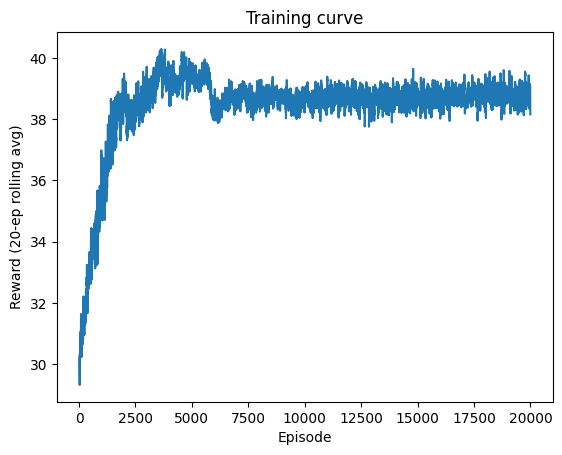

In [9]:
import numpy as np
audio_features_df = pd.read_csv("audio_features_df.csv")
rewards_df = pd.read_csv("rewards_with_motion.csv")
env   = DJEnvironment(audio_features_df, rewards_df, max_steps=20) #ok for this and the project lets leave it like that
                                                        # one step per song ~= 3min * 20 ~= 1 hour , like a typical dj set 
agent = QLearningAgent(state_size=env.state_size, n_actions=env.n_actions)

N_EPISODES = 20000
reward_log = []

for ep in range(N_EPISODES):
    state        = env.reset()
    total_reward = 0.0
    done         = False

    while not done:
        action                   = agent.select_action(state,env.played)
        next_state, reward, done = env.step(action)
        agent.update(state, action, reward, next_state, done)
        state        = next_state
        total_reward += reward

    reward_log.append(total_reward)
    # add the decay here instead per episode 
    if agent.epsilon > agent.epsilon_min:
        agent.epsilon *= agent.epsilon_decay

    if ep % 100 == 0:
        print(f"Ep {ep:4d} | reward: {total_reward:.3f} | ε: {agent.epsilon:.3f}")

import matplotlib.pyplot as plt
plt.plot(pd.Series(reward_log).rolling(20).mean())
plt.xlabel("Episode"); plt.ylabel("Reward (20-ep rolling avg)")
plt.title("Training curve"); plt.show()


In [12]:
state   = env.reset()
played  = {env.current_idx}

for _ in range(20):
    q_vals = agent.q_values(state).copy()
    q_vals[list(played)] = -np.inf          #  mask already-played tracks
    action = int(np.argmax(q_vals))

    state, _, done = env.step(action)
    played.add(action)
    row = env.tracks.iloc[env.current_idx]
    print(f"→ {row['song']:<55} | BPM: {row['bpm']:.0f}  energy: {row['energy_norm']:.2f}  dance: {row['danceability_norm']:.2f}")
    if done: break


→ Chase & Status ft. Masicka - Weed & Rum (VIP)           | BPM: 172  energy: 0.82  dance: 0.21
→ Chase & Status - ID                                     | BPM: 172  energy: 0.55  dance: 0.32
→ Dimension - UK (Bou Remix)                              | BPM: 172  energy: 0.30  dance: 0.22
→ TRANCEMAN2000 - Falling van Buuren                      | BPM: 162  energy: 0.23  dance: 0.35
→ DJ Break Da Law - Drosera                               | BPM: 162  energy: 0.23  dance: 0.05
→ + 16:00 AD†AM - NAK3D (Uphoria Remix)                   | BPM: 162  energy: 0.19  dance: 0.11
→ Veseli - Scream                                         | BPM: 162  energy: 0.05  dance: 0.17
→ Paul Johnson - Get Get Down                             | BPM: 138  energy: 0.03  dance: 0.68
→ Alignment - Close your eyes                             | BPM: 156  energy: 0.06  dance: 0.11
→ Marsh - Lailonie                                        | BPM: 135  energy: 0.08  dance: 0.42
→ Patrick Mason - Shred My Panties (Marl

In [13]:
import numpy as np

def run_random_policy(env, n_episodes=100):
    episode_rewards = []
    
    for ep in range(n_episodes):
        state = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            # Mask already-played songs and pick randomly from the rest
            available = [i for i in range(env.n_actions) if i not in env.played]
            action = np.random.choice(available)
            
            state, reward, done = env.step(action)
            total_reward += reward
        
        episode_rewards.append(total_reward)
    
    return episode_rewards

# Run it
random_rewards = run_random_policy(env, n_episodes=100)

print(f"Random Policy — Mean reward: {np.mean(random_rewards):.3f} ± {np.std(random_rewards):.3f}")
print(f"Min: {np.min(random_rewards):.3f}  Max: {np.max(random_rewards):.3f}")


Random Policy — Mean reward: 30.059 ± 1.869
Min: 24.299  Max: 36.610


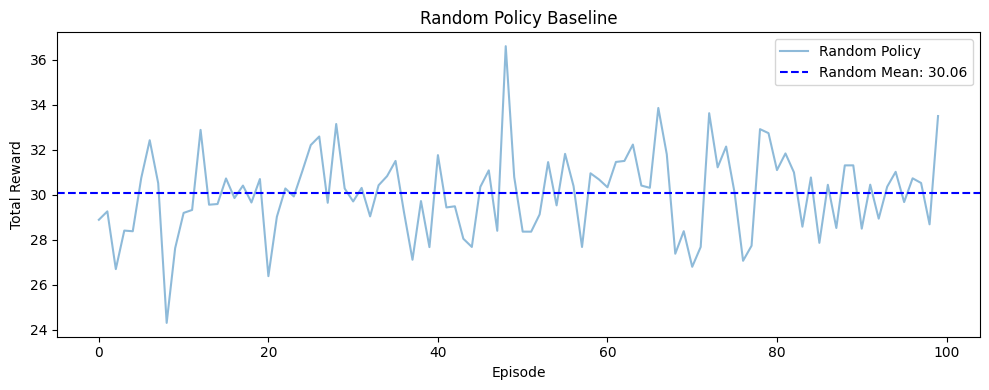

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(random_rewards, alpha=0.5, label='Random Policy')
# plt.plot(dqn_rewards, alpha=0.5, label='DQN Agent')   ← add this after training
plt.axhline(np.mean(random_rewards), color='blue', linestyle='--', label=f'Random Mean: {np.mean(random_rewards):.2f}')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Random Policy Baseline')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import importlib, env as env_module
from env import DJEnvironment

track_df  = pd.read_csv("audio_features_df.csv")
result_df = pd.read_csv("rewards_with_motion.csv")


In [20]:
import numpy as np
# save the Linear Q-Learning rewards to a file so the other notebook can read it, test_other_agents.ipynb
np.save('linear_q_rewards.npy', reward_log)


Training: Full (Audio + Sentiment + Motion)...


NameError: name 'train_q_learning' is not defined